In [1]:
from pathlib import Path
from functools import partial
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
data_dir = Path("D:/Data/NCAR")

In [3]:
flist = sorted(data_dir.glob("hgt.????.nc"))
print(flist)

[WindowsPath('D:/Data/NCAR/hgt.1979.nc'), WindowsPath('D:/Data/NCAR/hgt.1980.nc'), WindowsPath('D:/Data/NCAR/hgt.1981.nc'), WindowsPath('D:/Data/NCAR/hgt.1982.nc'), WindowsPath('D:/Data/NCAR/hgt.1983.nc'), WindowsPath('D:/Data/NCAR/hgt.1984.nc'), WindowsPath('D:/Data/NCAR/hgt.1985.nc'), WindowsPath('D:/Data/NCAR/hgt.1986.nc'), WindowsPath('D:/Data/NCAR/hgt.1987.nc'), WindowsPath('D:/Data/NCAR/hgt.1988.nc'), WindowsPath('D:/Data/NCAR/hgt.1989.nc'), WindowsPath('D:/Data/NCAR/hgt.1990.nc'), WindowsPath('D:/Data/NCAR/hgt.1991.nc'), WindowsPath('D:/Data/NCAR/hgt.1992.nc'), WindowsPath('D:/Data/NCAR/hgt.1993.nc'), WindowsPath('D:/Data/NCAR/hgt.1994.nc'), WindowsPath('D:/Data/NCAR/hgt.1995.nc'), WindowsPath('D:/Data/NCAR/hgt.1996.nc'), WindowsPath('D:/Data/NCAR/hgt.1997.nc'), WindowsPath('D:/Data/NCAR/hgt.1998.nc'), WindowsPath('D:/Data/NCAR/hgt.1999.nc'), WindowsPath('D:/Data/NCAR/hgt.2000.nc'), WindowsPath('D:/Data/NCAR/hgt.2001.nc'), WindowsPath('D:/Data/NCAR/hgt.2002.nc'), WindowsPath('D:

In [4]:
def _preprocess(ds):
    return ds[["hgt"]].sel(level=200.0)

In [5]:
ds = xr.open_mfdataset(flist, preprocess=partial(_preprocess))
ds = ds.sel(time=slice("1982", "2025"))
print(ds)

c:\Users\user\miniforge3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<xarray.Dataset> Size: 676MB
Dimensions:  (time: 16071, lat: 73, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 129kB 1982-01-01 1982-01-02 ... 2025-12-31
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    level    float32 4B 200.0
Data variables:
    hgt      (time, lat, lon) float32 676MB dask.array<chunksize=(1, 73, 144), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.0
    title:          daily NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalys

In [6]:
clim = ds["hgt"].groupby("time.dayofyear").mean(dim="time").compute()
print(clim)

<xarray.DataArray 'hgt' (dayofyear: 366, lat: 73, lon: 144)> Size: 15MB
array([[[10946.171 , 10946.171 , 10946.171 , ..., 10946.171 ,
         10946.171 , 10946.171 ],
        [10948.415 , 10948.722 , 10948.926 , ..., 10947.608 ,
         10947.824 , 10948.091 ],
        [10960.557 , 10961.125 , 10961.46  , ..., 10958.671 ,
         10959.4375, 10960.057 ],
        ...,
        [11188.512 , 11188.103 , 11187.796 , ..., 11189.397 ,
         11189.085 , 11188.841 ],
        [11177.807 , 11177.574 , 11177.335 , ..., 11178.557 ,
         11178.363 , 11178.085 ],
        [11174.619 , 11174.619 , 11174.619 , ..., 11174.619 ,
         11174.619 , 11174.619 ]],

       [[10956.358 , 10956.358 , 10956.358 , ..., 10956.358 ,
         10956.358 , 10956.358 ],
        [10961.488 , 10961.637 , 10961.637 , ..., 10961.244 ,
         10961.381 , 10961.483 ],
        [10972.449 , 10972.557 , 10972.647 , ..., 10971.421 ,
         10971.784 , 10972.182 ],
...
        [11174.943 , 11174.631 , 11174.329 , 

In [7]:
anom = ds["hgt"].groupby("time.dayofyear") - clim
print(anom)

<xarray.DataArray 'hgt' (time: 16071, lat: 73, lon: 144)> Size: 676MB
dask.array<sub, shape=(16071, 73, 144), dtype=float32, chunksize=(1, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 129kB 1982-01-01 1982-01-02 ... 2025-12-31
    level      (time) float32 64kB 200.0 200.0 200.0 200.0 ... 200.0 200.0 200.0
    dayofyear  (time) int64 129kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
Attributes: (12/14)
    long_name:      Daily Geopotential Heights on Pressure Levels
    units:          m
    precision:      0
    GRIB_id:        7
    GRIB_name:      HGT
    var_desc:       Geopotential height
    ...             ...
    statistic:      Mean
    parent_stat:    Individual Obs
    standard_name:  geopotential_height
    cell_methods:   time: mean (of 4 6-hourly values in one day)
    actual_ra

In [8]:
anom_jja = anom.sel(time=anom.time.dt.month.isin([6, 7, 8])).compute()
print(anom_jja)

<xarray.DataArray 'hgt' (time: 4048, lat: 73, lon: 144)> Size: 170MB
array([[[-20.89746   , -20.89746   , -20.89746   , ..., -20.89746   ,
         -20.89746   , -20.89746   ],
        [-32.6084    , -33.65332   , -34.57422   , ..., -30.545898  ,
         -31.69336   , -32.56836   ],
        [-49.82422   , -50.68164   , -51.375     , ..., -45.63086   ,
         -46.84082   , -48.7959    ],
        ...,
        [  4.4716797 ,   5.9941406 ,   7.625     , ...,  -2.102539  ,
           0.31835938,   1.9316406 ],
        [-43.1416    , -42.375     , -41.51172   , ..., -46.32422   ,
         -44.57422   , -43.83496   ],
        [-93.34082   , -93.34082   , -93.34082   , ..., -93.34082   ,
         -93.34082   , -93.34082   ]],

       [[-35.00586   , -35.00586   , -35.00586   , ..., -35.00586   ,
         -35.00586   , -35.00586   ],
        [-46.20996   , -47.11914   , -47.94336   , ..., -44.49414   ,
         -45.44922   , -46.36914   ],
        [-62.29004   , -63.09668   , -64.72754   , .

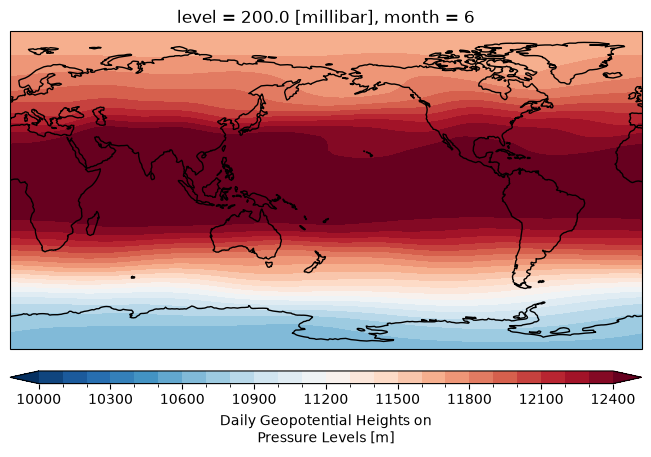

In [9]:
fig, ax = plt.subplots(
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
ds["hgt"].groupby("time.month").mean(dim="time")[5].plot.contourf(
    vmin=10000,
    vmax=12500,
    levels=np.arange(10000, 12500, 100),
    extend="both",
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs=dict(orientation="horizontal", aspect=50),
)
ax.coastlines()

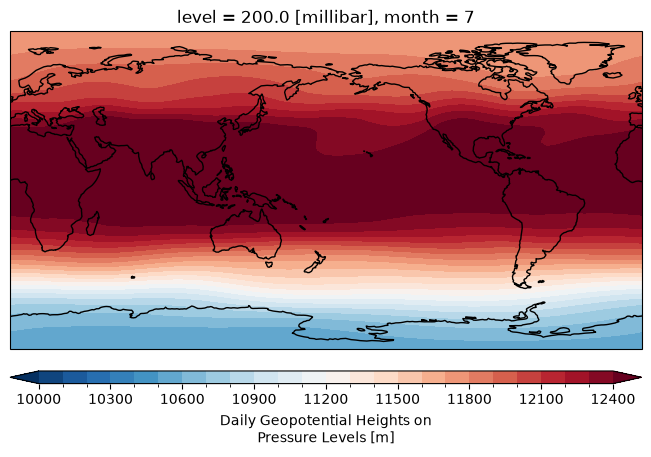

In [10]:
fig, ax = plt.subplots(
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
ds["hgt"].groupby("time.month").mean(dim="time")[6].plot.contourf(
    vmin=10000,
    vmax=12500,
    levels=np.arange(10000, 12500, 100),
    extend="both",
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs=dict(orientation="horizontal", aspect=50),
)
ax.coastlines()

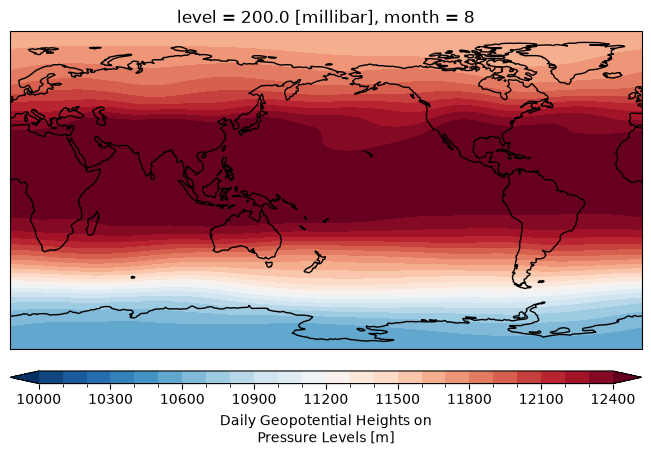

In [11]:
fig, ax = plt.subplots(
    layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
)
ds["hgt"].groupby("time.month").mean(dim="time")[7].plot.contourf(
    vmin=10000,
    vmax=16000,
    levels=np.arange(10000, 12500, 100),
    extend="both",
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs=dict(orientation="horizontal", aspect=50),
)
ax.coastlines()

In [12]:
anom_jja.to_netcdf("../../data/hgt_200_jja_1982_2025.nc")

In [13]:
import os

os.getcwd()

'c:\\Users\\user\\EASM\\notebooks\\preprocessing'